# Contextual Scouting — UEFA Euro 2024
## H4 — Player Similarity

Match players by how they actually play, not by their position label. Each player gets a "style DNA" built from the three earlier studies (H1 space control, H2 decision quality, H3 off-ball movement), and we find his closest matches inside the same role. The goal is the scouting question: *who plays like this expensive player, but costs less?*

Players are only compared **within their role**.

**Why no clustering.** The original plan was to cluster players into archetypes. We tried it, and on a single tournament it does not work: cluster across all roles and you just get the positions back (defenders with defenders), cluster inside a role and the groups are too small (20–65 players) to be stable. 

## Section 0 — Setup

In [ ]:
# Make `from src...` work when the notebook runs from notebooks/.
import sys, os
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src import similarity as sim

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Where the README figures are written. ROOT is the H4 project folder when the
# notebook runs from notebooks/; fall back to a docs/figures under it either way.
FIGDIR = ROOT / "docs" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("DNA axes (%d):" % len(cfg.DNA_AXES))
for a, l in zip(cfg.DNA_AXES, cfg.DNA_LABELS):
    print(f"  {l:20s}  <-  {a}")


def find_player(dna, name):
    """Locate a player row by StatsBomb name OR clean display name (Pedri, Rodri…).
    Returns the row, or raises a clear error if no match."""
    mask = dna["player"].str.contains(name, case=False, na=False) \
         | dna["display"].str.contains(name, case=False, na=False)
    hits = dna[mask]
    if hits.empty:
        raise KeyError(f"player not found: {name!r}")
    return hits.iloc[0]

## Section 1 — The player DNA

Every player is described by **11 numbers**, his "DNA". Each number is a within-role percentile (0–100) taken from the radar of one of the three studies:

- **H1 (space):** Progression, Dangerousness, Reception, Gravity
- **H2 (decisions):** Picks best, Avoids worst, Elite reads, Avoids poor
- **H3 (off-ball):** Off-Ball Potential, xEPV mean, Latency

We use these radar axes and leave out the two headline scores (H2's `DQ_index`, H3's `URS`), because each of those is just a summary of axes already in the list — keeping both would count the same thing twice.

In [2]:
dna = sim.load_dna()
print(f"DNA matrix: {len(dna)} players x {len(cfg.DNA_AXES)} axes")
print(f"missing values across axes: {int(dna[cfg.DNA_AXES].isna().sum().sum())}")
print("players per role:")
print(dna[cfg.ROLE_COL].value_counts().to_string())
dna.head()

DNA matrix: 272 players x 11 axes
missing values across axes: 0
players per role:
macro_role
MID     65
CB      61
FB      57
WIDE    37
FW      32
CAM     20


,player,team,macro_role,idx__PROGRESSION,idx__DANGEROUSNESS,idx__RECEPTION,idx__GRAVITY,pct__accuracy,pct__worst_choice,pct__elite_per90,pct__poor_per90,potential_pct_within_role,xepv_mean_pct_within_role,latency_pct_within_role,display
0,Christoph Baumgartner,Austria,CAM,45.0,85.0,85.0,100.0,100.0,25.0,55.0,65.0,30.0,85.0,25.0,Christoph Baumgartner
1,Pedro González López,Spain,CAM,97.5,35.0,100.0,62.5,50.0,70.0,95.0,55.0,100.0,95.0,100.0,Pedri
2,Fabian Rieder,Switzerland,CAM,20.0,95.0,65.0,80.0,65.0,65.0,30.0,85.0,40.0,90.0,60.0,Fabian Rieder
3,Kevin De Bruyne,Belgium,CAM,97.5,70.0,45.0,55.0,75.0,60.0,85.0,35.0,75.0,30.0,35.0,Kevin De Bruyne
4,Daniel Olmo Carvajal,Spain,CAM,60.0,75.0,80.0,50.0,80.0,75.0,65.0,75.0,55.0,50.0,10.0,Daniel Carvajal


### How the similarity score works

**Step 1 — measure the distance.** We use the straight-line (Euclidean) distance between the two points:

$$d(A,B) = \sqrt{\sum_{i=1}^{11}(a_i - b_i)^2}$$

If two players have the exact same DNA, the distance is 0. The more their numbers differ, the bigger the distance.

**Step 2 — turn the distance into a 0–100 score.** A distance is hard to read, so we rescale it so that *no distance = 100%* and *the biggest possible distance = 0%*:

$$\text{similarity} = \left(1 - \frac{d}{D}\right) \times 100$$

For $D$ we use the **largest distance two players could ever have**: every axis runs 0–100, so the biggest gap on one axis is 100, and across all 11 axes that is

$$D = \sqrt{11 \times 100^2} = \sqrt{11}\times 100 \approx 331.7$$

This $D$ is a fixed number — it comes from the shape of the data (11 axes, each 0–100), not from the players. So a pair's score only depends on those two players. Adding or removing other players never changes it.

*Example:* Rodri and Jorginho are at distance 61.1, which gives $(1 - 61.1/331.7)\times 100 \approx 82\%$.

**Why a fixed $D$ and not a "min–max" one.** A popular shortcut is to stretch the scores so the closest real pair becomes 100% and the most different becomes 0%. We avoid it: that kind of score is unstable (one odd player shifts everyone else's number), and it forces a 100% and a 0% to exist even when no real pair is that close or that far apart. Our fixed $D$ gives a score that always means the same thing.

The trade-off is only cosmetic: real scores land roughly in the **23–88%** range, not the full 0–100, because two real footballers are never identical and never total opposites. So read 88% as *"about as alike as two players ever get here"*, not as "only 88". 

### Why we re-rank every axis to a percentile

Straight-line distance gives more weight to any axis that is more spread out. The H2 and H3 axes already arrive as percentiles (evenly spread 0–100), but the H1 indices are built differently and are more bunched up. Left alone, the H1 axes — **Gravity** worst of all — would count for much less than the others.

The fix in `load_dna()` is simple: we re-rank **every** axis to a within-role percentile. After that, all 11 axes are on the same scale, so each one carries an equal **9.1%** of the distance and the three studies count the same.

This matters in practice, it is not just tidying up. Without it, Gravity carries only **3.7%** of the distance instead of 9.1%, and that is enough to change the result: the single closest match flips for **26%** of players. So the re-ranking is fixing a real problem, not a cosmetic one.

### Why 11 axes and not just 6

We could use a shorter DNA: one number per headline concept (the 4 H1 indices, plus H2's `DQ_index` and H3's `URS`), so **6 numbers** instead of 11. It looks tidier. We tested it against the 11-axis version and kept the 11. Two reasons:

- **It is more stable.** Remove one axis and re-check the matches: with 11 axes the top-5 stay the same 83.5% of the time, with 6 axes only 72.8%. With just 6 numbers each one carries too much weight, so the result wobbles more.
- **It makes more football sense.** The two versions disagree on the closest match for 71% of players, and when they do, the 11-axis answer is the better one. The 6-axis version only sees the *overall level* of decisions and off-ball play, so it pairs players who reach that level in very different ways — it puts a ball-winner (Kanté) top for a deep playmaker (Rodri), or a finisher next to a dribbling winger. The 11 axes keep the detail of *how* a player decides and moves, which is exactly what "plays like X" needs.


## Section 2 — Are any axes saying the same thing?

Straight-line distance assumes the 11 axes are independent. If two axes really measure the same thing, that thing gets counted twice. So we check how correlated the axes are within a role. We want mostly low numbers; anything above about 0.6 is worth a note, but we keep correlated axes and just flag them — the same approach H2 and H3 use for their own radars.

In [3]:
red = sim.axis_redundancy(dna)
# show only the off-diagonal pairs above a threshold, plus the full matrix
pairs = []
labs = list(red.columns)
for i in range(len(labs)):
    for j in range(i+1, len(labs)):
        pairs.append((labs[i], labs[j], red.iloc[i, j]))
pairs = sorted(pairs, key=lambda t: -t[2])
print("Most correlated axis pairs (within-role |rho|):")
for a, b, r in pairs[:6]:
    print(f"  {r:.2f}  {a}  x  {b}")
print()
red

Most correlated axis pairs (within-role |rho|):
  0.66  Avoids poor/90  x  Off-Ball Potential
  0.58  Elite reads/90  x  Off-Ball Potential
  0.56  Off-Ball Potential  x  xEPV mean
  0.55  Progression  x  Dangerousness
  0.49  Picks best  x  Elite reads/90
  0.46  Progression  x  Off-Ball Potential



,Progression,Dangerousness,Reception,Gravity,Picks best,Avoids worst,Elite reads/90,Avoids poor/90,Off-Ball Potential,xEPV mean,Latency
Progression,0.00,0.55,0.07,0.13,0.06,0.04,0.44,0.34,0.46,0.32,0.07
Dangerousness,0.55,0.00,0.13,0.17,0.10,0.08,0.23,0.22,0.23,0.28,0.09
Reception,0.07,0.13,0.00,0.13,0.13,0.14,0.20,0.00,0.11,0.02,0.05
Gravity,0.13,0.17,0.13,0.00,0.12,0.09,0.12,0.07,0.13,0.00,0.00
Picks best,0.06,0.10,0.13,0.12,0.00,0.05,0.49,0.36,0.25,0.13,0.04
Avoids worst,0.04,0.08,0.14,0.09,0.05,0.00,0.20,0.32,0.10,0.07,0.01
Elite reads/90,0.44,0.23,0.20,0.12,0.49,0.20,0.00,0.35,0.58,0.12,0.02
Avoids poor/90,0.34,0.22,0.00,0.07,0.36,0.32,0.35,0.00,0.66,0.25,0.00
Off-Ball Potential,0.46,0.23,0.11,0.13,0.25,0.10,0.58,0.66,0.00,0.56,0.08
xEPV mean,0.32,0.28,0.02,0.00,0.13,0.07,0.12,0.25,0.56,0.00,0.15


Every pair sits at or below 0.66, and most are far lower. The handful that stand out are all football-sensible: a player who *avoids poor decisions* and reads space well (Avoids poor/90, Elite reads/90) tends to have high *Off-Ball Potential*, and *Progression* travels with *Dangerousness*. None of these are high enough to be measuring the same thing twice, so we keep all 11 axes and simply note the overlap.

## Section 3 — Do the matches make sense?

We pick well-known players and look at who comes up as their closest matches. If the method works, each player's matches should be his obvious stylistic family — deep playmakers next to deep playmakers, ball-playing centre-backs next to ball-playing centre-backs — not a random list of same-role players.

In [4]:
for name in ["Rodri", "Toni Kroos", "Pedri", "Kimmich",
             "Rüdiger", "Bellingham", "Lamine", "Bastoni"]:
    try:
        src = find_player(dna, name)
    except KeyError:
        print(f"  [{name} not found]\n"); continue
    res = sim.neighbours(dna, src["player"], src["team"], top_k=6)
    print(f"{src['display']} ({src['team']}, {src['macro_role']}):")
    for _, r in res.iterrows():
        print(f"   {r['similarity']:5.1f}  {r['display'][:24]:24s} {r['team']}")
    print()

Rodri (Spain, MID):
    81.6  Jorginho                 Italy
    80.7  Morten Hjulmand          Denmark
    79.5  Jerdy Schouten           Netherlands
    79.5  Mateo Kovacic            Croatia
    78.2  Granit Xhaka             Switzerland
    76.3  Hakan Çalhanoğlu         Turkey

Toni Kroos (Germany, MID):
    82.2  Aurélien Tchouaméni      France
    81.6  Joey Veerman             Netherlands
    77.4  Vitinha                  Portugal
    77.4  Martín Zubimendi         Spain
    75.0  Youri Tielemans          Belgium
    74.3  Trent Alexander-Arnold   England

Pedri (Spain, CAM):
    73.7  Orkun Kökçü              Turkey
    70.0  Christian Eriksen        Denmark
    65.2  Jonas Wind               Denmark
    64.5  Jude Bellingham          England
    64.5  İlkay Gündoğan           Germany
    63.6  Kevin De Bruyne          Belgium

Joshua Kimmich (Germany, FB):
    74.7  Maximilian Mittelstädt   Germany
    73.6  Daniel Carvajal          Spain
    73.3  João Cancelo             P

Each player's list is his stylistic family, not just his position: Rodri lands next to other deep, controlling midfielders (Jorginho, Hjulmand, Kovačić, Xhaka); Kroos next to the metronomic passers (Tchouaméni, Zubimendi, Vitinha); Pedri and Bellingham next to creative number-eights/tens (Kökçü, Eriksen, De Bruyne, Gündoğan); Rüdiger and Bastoni next to ball-playing centre-backs (Tah, Laporte, Andersen); Lamine Yamal next to the elite wide dribblers (Saka, Leão, Williams, Dembélé). 

## Section 4 — The output table

This builds the final file the website reads to show similar players. It saves two things: each player's DNA, and the full list of within-role matches with their scores.

After saving, two quick views: a **table** of players next to their single closest match, and a **bar chart** of the strongest matches in the whole pool, so you can sanity-check the output at a glance.

In [5]:
# Write the two outputs (per-player DNA + the long similarity table).
# top_k=None stores EVERY within-role pair, so the website can rank and page
# through all same-role candidates in its "Compare With" picker. (cfg.TOP_K is
# only for the compact notebook views above, not for the shipped artefact.)
dna_out, sim_table = sim.build(top_k=None, metric="euclidean", write=True)
print(f"DNA written      : {cfg.DNA_PATH}  ({len(dna_out)} players)")
print(f"similarity table : {cfg.SIMILARITY_PATH}  ({len(sim_table)} rows)")
print(f"score range      : {sim_table['similarity'].min():.1f} - {sim_table['similarity'].max():.1f}")

# map StatsBomb names -> clean display names for readable output
name2disp = dict(zip(dna["player"], dna["display"]))

# ── View 1: each player next to his single closest match (rank == 1) ──────────
closest = (sim_table[sim_table["rank"] == 1]
           .loc[:, ["source_player", "macro_role", "neighbour_player", "similarity"]]
           .rename(columns={"source_player": "Player",
                            "macro_role": "Role",
                            "neighbour_player": "Closest match",
                            "similarity": "Score"})
           .sort_values("Score", ascending=False)
           .reset_index(drop=True))
closest["Score"] = closest["Score"].round(1)
closest["Player"] = closest["Player"].map(name2disp).fillna(closest["Player"])
closest["Closest match"] = closest["Closest match"].map(name2disp).fillna(closest["Closest match"])

# Similarity is symmetric, so each strong pair shows up twice in `closest`
# (A->B and B->A, same score). For the "strongest pairs" views we collapse each
# unordered pair {A, B} to one row; the per-player table keeps both, since there
# it legitimately answers "who is *this* player's closest match".
closest["_pair"] = closest.apply(lambda r: frozenset((r["Player"], r["Closest match"])), axis=1)
pairs_unique = closest.drop_duplicates("_pair").drop(columns="_pair").reset_index(drop=True)
disp = closest.drop(columns="_pair")

print(f"\nClosest match for each player (n = {len(disp)}), top of the list:")
disp.head(40)

DNA written      : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/H4_Player_Similarity/data/player_dna.csv  (272 players)
similarity table : /Users/matteovezzoli/Desktop/Contextual-Football-Scouting/H4_Player_Similarity/data/player_similarity.csv  (13716 rows)
score range      : 23.0 - 87.7

Closest match for each player (n = 272), top of the list:


,Player,Role,Closest match,Score
0,John Stones,CB,Marc Guéhi,87.7
1,Marc Guéhi,CB,John Stones,87.7
2,Kyle Walker,FB,Giovanni Di Lorenzo,87.2
3,Giovanni Di Lorenzo,FB,Kyle Walker,87.2
4,Bukayo Saka,WIDE,Lamine Yamal,86.8
5,Lamine Yamal,WIDE,Bukayo Saka,86.8
6,Georges Mikautadze,FW,Denis Drăguș,86.2
7,Denis Drăguș,FW,Georges Mikautadze,86.2
8,Timi Max Elsnik,MID,Nicolae Stanciu,85.9
9,Nicolae Stanciu,MID,Timi Max Elsnik,85.9


In [ ]:
# ── View 2: bar chart of the strongest *unique* pairs in the pool ────────────
top_n = 25
top = pairs_unique.head(top_n).iloc[::-1]
labels = [f"{p}  →  {m}" for p, m in zip(top["Player"], top["Closest match"])]

roles = top["Role"].unique()
palette = dict(zip(roles, plt.cm.tab10.colors))
colors = [palette[r] for r in top["Role"]]

fig, ax = plt.subplots(figsize=(9, top_n * 0.34))
ax.barh(range(len(top)), top["Score"], color=colors, edgecolor="white", height=0.7)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlim(0, 100)
ax.set_xlabel("Similarity score (100 = identical DNA)")
ax.set_title(f"Top {top_n} closest player pairs (within macro-role)", fontsize=11)
for i, v in enumerate(top["Score"]):
    ax.text(v + 0.5, i, f"{v:.1f}", va="center", fontsize=7.5)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=palette[r], label=r) for r in roles],
          loc="lower right", fontsize=8, title="Role")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGDIR / "top_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5 — Checking the result holds up

Three quick checks tell us the similarity is a real signal, not an accident:

1. **Not just teammates.** If a player's closest match were usually a teammate, we would be measuring "same team", not style. This share should be low.
2. **Doesn't hang on one axis.** Drop each axis in turn and re-check the top-5. If they mostly survive, no single axis is driving the result.
3. **It actually separates players.** Some players should have a close twin, others should be more one-of-a-kind. 

In [ ]:
import numpy as np

# 1) team independence — share of nearest matches that are teammates
src_team = dict(zip(dna["player"], dna["team"]))
top1_tbl = sim.build_similarity_table(dna, top_k=1)
same_team = np.mean([src_team.get(s) == nt
                     for s, nt in zip(top1_tbl["source_player"], top1_tbl["neighbour_team"])])

# 2) stability under axis removal — top-5 overlap, averaged over a sample
AX = cfg.DNA_AXES
mat = dna[AX].to_numpy(float); names = dna["player"].values; roles = dna[cfg.ROLE_COL].values
def top5(idx, drop=None):
    use = [k for k in range(len(AX)) if k != drop]
    d = np.sqrt(((mat[:, use] - mat[idx, use]) ** 2).sum(1))
    ranked = [j for j in np.argsort(d) if roles[j] == roles[idx] and j != idx]
    return set(names[j] for j in ranked[:5])
rng = np.random.default_rng(0)
sample = rng.choice(len(dna), 40, replace=False)
overlaps = [len(top5(i) & top5(i, d)) / 5 for i in sample for d in range(len(AX))]
stability = np.mean(overlaps)

# 3) score distribution
s1 = top1_tbl["similarity"]

print(f"1. nearest-match teammates       : {same_team:.1%}   (low = style, not team)")
print(f"2. top-5 stability (drop 1 axis) : {stability:.1%}   (high = no single axis dominates)")
print(f"3. top-1 score  min/median/max   : {s1.min():.1f} / {s1.median():.1f} / {s1.max():.1f}")
print(f"   strong twins (>85): {(s1>85).sum()}   |   more unique (<75): {(s1<75).sum()}")

# plot the score distribution
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(s1, bins=30, color="#6366f1", edgecolor="white")
ax.axvline(s1.median(), color="#db2777", ls="--", lw=1.5, label=f"median {s1.median():.1f}")
ax.set_xlabel("Best-match similarity score"); ax.set_ylabel("players")
ax.set_title("How close is each player's nearest stylistic match?")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(FIGDIR / "best_match_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Only **10.3%** of nearest matches are teammates, so the metric is reading style, not shared team. Top-5 matches survive dropping any single axis **83.5%** of the time, so no one axis is carrying the result. And the best-match scores spread out properly (65–88, median 79) — **14** players have a strong stylistic twin (>85) while **47** are more one-of-a-kind (<75), which is exactly what a metric that genuinely separates players should look like.

## Section 6 — The radar picture

This is the chart the website uses. It puts two players' DNA on the same radar (same role only). Overlapping shapes mean similar players. It shows two things at once: a **close match** (the two shapes sit almost on top of each other) and a **contrast** (two players of the same role pull apart). That is the visual proof the metric both finds look-alikes and tells players apart.

Below: the closest pair in each role, then one player against his nearest and his furthest match.

In [ ]:
def _vec(name):
    row = find_player(dna, name)
    return row, row[cfg.DNA_AXES].to_numpy(float)

def dna_radar(ax, p1, p2, score=None):
    """Overlay two players' 11-axis DNA on a polar axis."""
    r1, v1 = _vec(p1); r2, v2 = _vec(p2)
    labels = cfg.DNA_LABELS
    ang = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist(); ang += ang[:1]
    # Rotate the wheel half a step and start from the top so no axis label sits
    # directly under the title (that overlap is what made "Gravity" collide with
    # the role title before).
    ax.set_theta_offset(np.pi/2 + np.pi/len(labels))
    ax.set_theta_direction(-1)
    for r, v, col in [(r1, v1, "#2563eb"), (r2, v2, "#db2777")]:
        vv = np.concatenate([v, v[:1]])
        ax.plot(ang, vv, color=col, linewidth=1.8, label=f"{r['display']} ({r['team']})")
        ax.fill(ang, vv, color=col, alpha=0.12)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=6.5)
    ax.set_yticks([25, 50, 75]); ax.set_yticklabels([], fontsize=6); ax.set_ylim(0, 100)
    ax.tick_params(axis="x", pad=6)
    title = f"{r1[cfg.ROLE_COL]}"
    if score is not None: title += f"  ·  similarity {score:.0f}"
    # y above the axes (instead of a small pad) keeps the title clear of the labels
    ax.set_title(title, fontsize=9, y=1.14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.20), fontsize=6.5, frameon=False)

# ── Grid: the closest pair in six roles ──────────────────────────────────────
pairs = [
    ("John Stones", "Marc Guehi", 87.7),          # CB
    ("Kyle Walker", "Giovanni Di Lorenzo", 87.2),  # FB
    ("Lamine Yamal", "Bukayo Saka", 86.8),         # WIDE
    ("Timi Elšnik", "Nicolae Claudiu Stan", 85.9), # MID
    ("Georges Mikautadze", "Denis Mihai", 86.2),   # FW
    ("Jonas Older Wind", "Christian Dannemann", 82.1),  # CAM
]
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
for ax, (a, b, s) in zip(axes.ravel(), pairs):
    dna_radar(ax, a, b, s)
fig.suptitle("DNA overlays — the closest stylistic pair in each role", fontsize=13, y=1.0)
plt.tight_layout()
fig.savefig(FIGDIR / "dna_overlay_by_role.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Contrast: a player's nearest vs furthest match in his role ───────────────
def nearest_and_furthest(name):
    row = find_player(dna, name)
    pool = dna[(dna[cfg.ROLE_COL] == row[cfg.ROLE_COL]) & (dna["player"] != row["player"])].copy()
    d = np.sqrt(((pool[cfg.DNA_AXES].to_numpy(float) - row[cfg.DNA_AXES].to_numpy(float)) ** 2).sum(1))
    pool["s"] = (1 - d / (np.sqrt(len(cfg.DNA_AXES)) * 100)) * 100
    pool = pool.sort_values("s")
    return row, pool.iloc[-1], pool.iloc[0]

target = "Rodri"
src, near, far = nearest_and_furthest(target)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6), subplot_kw=dict(polar=True))
# dna_radar already sets a (role · similarity) title with y=1.14; overwrite with
# the same y so the nearest/furthest label stays clear of the axis labels too.
dna_radar(axL, src["player"], near["player"], near["s"]); axL.set_title(f"{src['display']} vs nearest", fontsize=10, y=1.14)
dna_radar(axR, src["player"], far["player"],  far["s"]);  axR.set_title(f"{src['display']} vs furthest", fontsize=10, y=1.14)
fig.suptitle("Same role, opposite outcome — the metric discriminates", fontsize=12, y=1.04)
plt.tight_layout()
fig.savefig(FIGDIR / "contrast_nearest_furthest.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7 — The use case: finding cheaper look-alikes

This is what H4 is for. Pick an expensive player, and find the players with the most similar style who cost less — the "same kind of player, lower price" question.

Two choices worth explaining:

- **We use the pre-Euro price.** The DNA is built on Euro 2024 performance, so the price *after* the tournament already reflects how the player did. To find a real bargain we use the price from *before* the Euros — who a club could have signed cheaply before the tournament showed his quality.
- **We keep the post-Euro price as a check.** Since we also have the later price, we can see whether the cheap look-alikes actually went up in value afterwards. If they did, the method is spotting genuinely undervalued players.

The score is shown next to every name, so you can see how close each match really is.

In [10]:
mv = sim.load_market_values()

def fmt_eur(v):
    if pd.isna(v): return "—"
    return f"€{v/1e6:.1f}M" if v >= 1e6 else f"€{v/1e3:.0f}K"

def arbitrage(target, k=12):
    """Cheaper stylistic alternatives to a premium target, ranked by pre-Euro price."""
    tgt = find_player(dna, target)
    nb = sim.neighbours(dna, tgt["player"], tgt["team"], top_k=k)
    if mv is not None:
        nb = nb.merge(mv, on=["player", "team"], how="left")
    tgt_mv = mv[mv["player"] == tgt["player"]]["mv_pre"].iloc[0] if mv is not None else None

    print(f"Target: {tgt['display']} ({tgt['team']}, {tgt['macro_role']})"
          + (f"  —  pre-Euro value {fmt_eur(tgt_mv)}" if tgt_mv is not None else ""))
    print("Cheapest stylistic look-alikes (most similar neighbours, ranked by price):\n")
    if mv is not None:
        cheaper = nb[nb["mv_pre"] < tgt_mv].sort_values("mv_pre") if tgt_mv is not None else nb
        print(f"   {'sim':>4}  {'player':24}{'team':14}{'pre-Euro':>10}{'post-Euro':>11}")
        for _, r in cheaper.iterrows():
            arrow = ""
            if pd.notna(r.get("mv_pre")) and pd.notna(r.get("mv_post")):
                arrow = " up" if r["mv_post"] > r["mv_pre"] else (" down" if r["mv_post"] < r["mv_pre"] else " =")
            print(f"   {r['similarity']:4.0f}  {r['display'][:23]:24}{r['team'][:13]:14}"
                  f"{fmt_eur(r.get('mv_pre')):>10}{fmt_eur(r.get('mv_post')):>11}{arrow}")
    else:
        for _, r in nb.iterrows():
            print(f"   {r['similarity']:4.0f}  {r['display'][:23]:24}{r['team']}")
        print("   (market-value files not found — showing similarity only)")
    return nb

_ = arbitrage("Rodri")

Target: Rodri (Spain, MID)  —  pre-Euro value €120.0M
Cheapest stylistic look-alikes (most similar neighbours, ranked by price):

    sim  player                  team            pre-Euro  post-Euro
     74  N'Golo Kanté            France             €9.0M      €7.0M down
     82  Jorginho                Italy             €12.0M     €10.0M down
     73  Robert Andrich          Germany           €17.0M     €15.0M down
     78  Granit Xhaka            Switzerland       €20.0M     €17.0M down
     80  Jerdy Schouten          Netherlands       €28.0M     €35.0M up
     80  Mateo Kovacic           Croatia           €30.0M     €28.0M down
     74  Fabián Ruiz             Spain             €30.0M     €35.0M up
     74  Tijjani Reijnders       Netherlands       €30.0M     €50.0M up
     74  Adrien Rabiot           France            €35.0M     €30.0M down
     81  Morten Hjulmand         Denmark           €40.0M     €45.0M up
     76  Hakan Çalhanoğlu        Turkey            €45.0M     €40.0M 

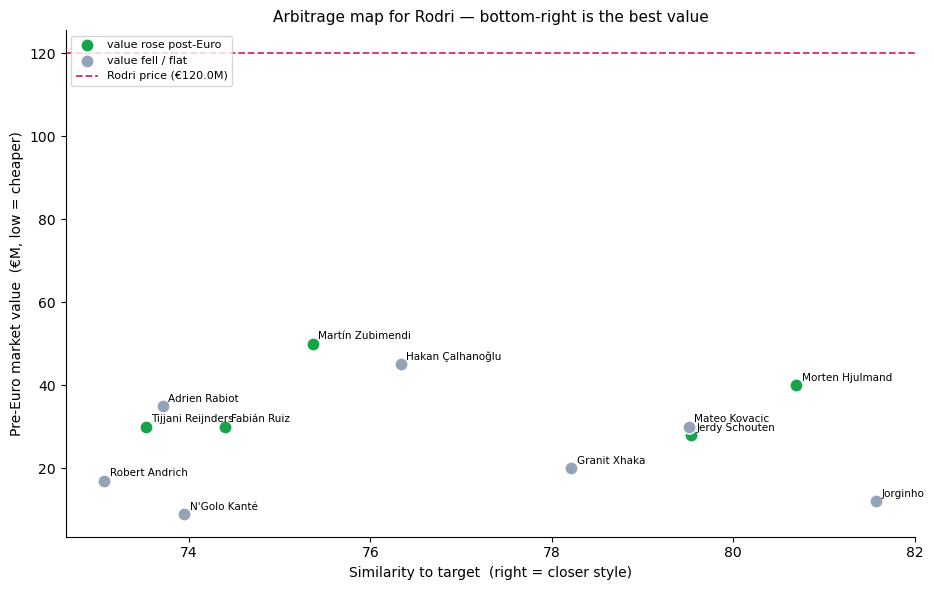

In [11]:
# ── The arbitrage map: similarity vs price ───────────────────────────────────
# x = how close a stylistic match (right = closer); y = pre-Euro price (low =
# cheaper). The sweet spot is the BOTTOM-RIGHT: very similar AND cheap. Marker
# colour shows the post-Euro back-test (green = the look-alike's value rose).
def arbitrage_map(target, k=12):
    tgt = find_player(dna, target)
    nb = sim.neighbours(dna, tgt["player"], tgt["team"], top_k=k)
    if mv is None:
        print("market-value files not found — skipping the map"); return
    nb = nb.merge(mv, on=["player", "team"], how="left").dropna(subset=["mv_pre"])
    tgt_mv = mv[mv["player"] == tgt["player"]]["mv_pre"].iloc[0]

    rose = nb["mv_post"] > nb["mv_pre"]
    fig, ax = plt.subplots(figsize=(9.5, 6))
    ax.scatter(nb.loc[rose, "similarity"],  nb.loc[rose, "mv_pre"]/1e6,
               s=90, color="#16a34a", edgecolor="white", label="value rose post-Euro", zorder=3)
    ax.scatter(nb.loc[~rose, "similarity"], nb.loc[~rose, "mv_pre"]/1e6,
               s=90, color="#94a3b8", edgecolor="white", label="value fell / flat", zorder=3)
    ax.axhline(tgt_mv/1e6, color="#db2777", ls="--", lw=1.3,
               label=f"{tgt['display']} price ({fmt_eur(tgt_mv)})")
    for _, r in nb.iterrows():
        ax.annotate(r["display"], (r["similarity"], r["mv_pre"]/1e6),
                    fontsize=7.5, xytext=(4, 3), textcoords="offset points")
    ax.set_xlabel("Similarity to target  (right = closer style)")
    ax.set_ylabel("Pre-Euro market value  (€M, low = cheaper)")
    ax.set_title(f"Arbitrage map for {tgt['display']} — bottom-right is the best value", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

arbitrage_map("Rodri")